# Assignment 2: Multilevel Models for Educational Data
**Advanced Statistical Learning and Modeling - Module B**

## 1. Data Preparation

First, we import the required libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel('../INVALSI_data_MAT_2324.xlsx')
print(f"Initial shape: {df.shape}")


/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-ozzesn26 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Initial shape: (16244, 84)


### Data Cleaning and Variable Selection

We select the suggested variables and handle missing values. Categorical variables often use `9` or `99` to indicate missing or unknown information. We will map these to `NaN` and then drop rows with missing data for our model variables.

**Rationale for Variable Selection:**
- `gender`, `origin`, `month`, `year`: Basic demographic controls.
- `nursery_attendance`, `kindergarten_attendance`: Early education history.
- `father_education`, `mother_education`, `father_occupation`, `mother_occupation`: Family socio-economic indicators.
- `ESCS_student`, `ESCS_class`: Standardized indices of economic, social, and cultural status at the student and class levels.
- `GeoArea_5`: Geographical context.
- `WLE_MATH_200`: Chosen as the continuous response variable. It represents the standardized math score estimated via Item Response Theory (IRT), which is highly suitable for linear mixed-effects modeling.


In [2]:
cols = ['SCHOOL_ANONYMIZED', 'CLASS_ANONYMIZED', 'gender', 'month', 'year', 'origin', 
        'nursery_attendance', 'kindergarten_attendance', 'father_education', 'mother_education', 
        'father_occupation', 'mother_occupation', 'Region_Code', 'GeoArea_5', 
        'ESCS_student', 'ESCS_class', 'WLE_MATH_200']

data = df[cols].copy()

# Replace missing value codes
data.replace(' ', np.nan, inplace=True)
data['ESCS_student'] = pd.to_numeric(data['ESCS_student'], errors='coerce')

# Convert 9 and 99 to NaN for categorical variables
for col in ['origin', 'nursery_attendance', 'kindergarten_attendance']:
    data[col] = data[col].replace(9, np.nan)
    
for col in ['father_education', 'mother_education', 'father_occupation', 'mother_occupation']:
    data[col] = data[col].replace(99, np.nan)

# Drop missing values
data_clean = data.dropna().copy()
print(f"Shape after cleaning: {data_clean.shape}")

# Create a unique class identifier
data_clean['school_class'] = data_clean['SCHOOL_ANONYMIZED'].astype(str) + '_' + data_clean['CLASS_ANONYMIZED'].astype(str)


Shape after cleaning: (9623, 17)


## 2. Response Variable and Variable Classification

**Response Variable**: `WLE_MATH_200`
We chose `WLE_MATH_200` because it is a robust IRT-based continuous standardized score, making it ideal for a Gaussian linear mixed model.

**Variable Classification**:
- **Individual-level variables**: `gender`, `month`, `year`, `origin`, `nursery_attendance`, `kindergarten_attendance`, `father_education`, `mother_education`, `father_occupation`, `mother_occupation`, `ESCS_student`.
- **School/Class-level variables**: `ESCS_class` (aggregated at the class level).
- **Contextual variables**: `Region_Code`, `GeoArea_5` (geographical macro-areas).

## 3. Modeling

We fit a multilevel (mixed-effects) model to account for the hierarchical structure: students are nested within classes, which are nested within schools.
We will include a random intercept for the school (`SCHOOL_ANONYMIZED`) and a nested random effect for the class (`school_class`). This structure accounts for unobserved heterogeneity at both the school and classroom levels, which is standard for educational data.


In [3]:
# Define the model formula
formula = (
    "WLE_MATH_200 ~ C(gender) + month + year + C(origin) + "
    "C(nursery_attendance) + C(kindergarten_attendance) + "
    "C(father_education) + C(mother_education) + "
    "C(father_occupation) + C(mother_occupation) + "
    "ESCS_student + ESCS_class + C(GeoArea_5)"
)

# Fit the Mixed Linear Model
# We use SCHOOL_ANONYMIZED as the main group (Level 3), and school_class as a variance component (Level 2).
vcf = {'class': '0 + C(school_class)'}
model = smf.mixedlm(formula, data_clean, groups=data_clean['SCHOOL_ANONYMIZED'], vc_formula=vcf)

# Fit the model
result = model.fit()
print(result.summary())


                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        WLE_MATH_200
No. Observations:         9623           Method:                    REML        
No. Groups:               400            Scale:                     1030.0498   
Min. group size:          1              Log-Likelihood:            -47377.5607 
Max. group size:          51             Converged:                 Yes         
Mean group size:          24.1                                                  
--------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                         200.738    6.378  31.475 0.000 188.238 213.238
C(gender)[T.2]                    -10.119    0.672 -15.062 0.000 -11.436  -8.802
C(origin)[T.2.0]                  -10.637    2.347

## 4. Diagnostics and Interpretation

### Interpretation of Fixed and Random Effects
- **Fixed Effects**: The coefficients indicate the effect of each predictor on the math score (`WLE_MATH_200`). For instance, the coefficient for `ESCS_student` shows the expected increase in the math score for a one-unit increase in the student's socio-economic status, holding other variables constant. Similarly, `ESCS_class` captures the peer/class-level socio-economic effect.
- **Random Effects**: The variances for the school group (`Group Var`) and the class variance component (`class Var`) represent the variability in math scores attributable to differences between schools and between classes within schools. A non-zero variance indicates that the hierarchical structure is meaningful and that intra-class correlation exists.

### Diagnostics
We will plot the residuals to assess homoscedasticity and normality, which are key assumptions of linear mixed models.


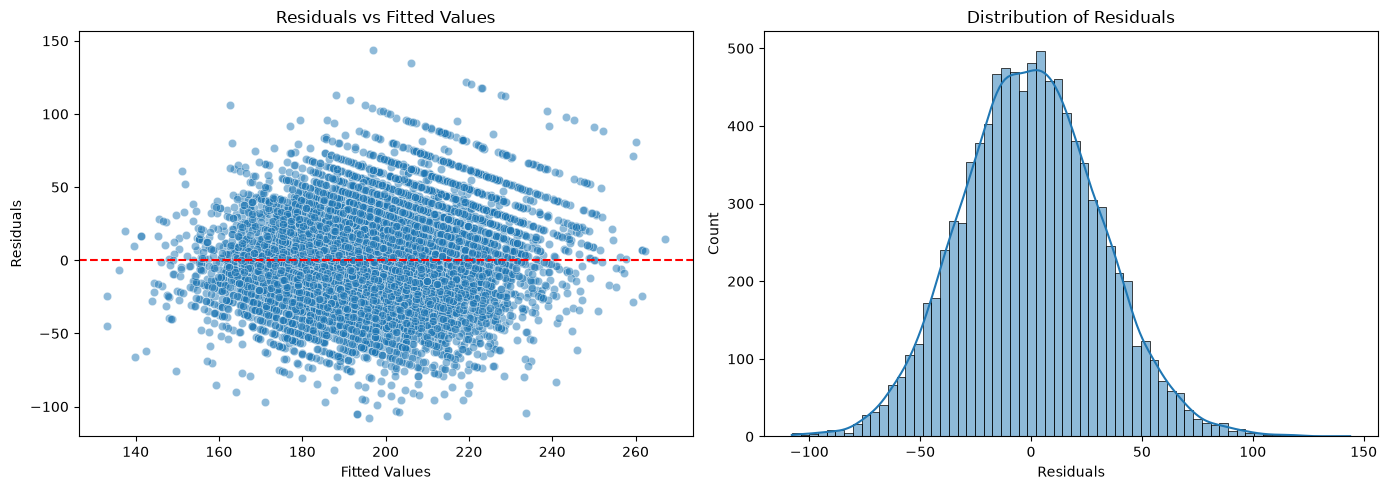

In [4]:
# Residuals plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Fitted values vs Residuals
sns.scatterplot(x=result.fittedvalues, y=result.resid, alpha=0.5, ax=ax[0])
ax[0].axhline(0, color='r', linestyle='--')
ax[0].set_xlabel("Fitted Values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs Fitted Values")

# Histogram of Residuals
sns.histplot(result.resid, kde=True, ax=ax[1])
ax[1].set_xlabel("Residuals")
ax[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.savefig('residuals_plot.png')
plt.show()
